# Nonconex Quadratic Semidefinite Programming
## Problem

We want to solve

$$\min\limits_{X\in\mathbb{R}^{n\times n}} f(X) + \iota_{\mathcal{C}}(X) + \|X\|_1$$
where 
$$\mathcal{C} = \{U\in\mathbb{R}^{n\times n}\colon U \succcurlyeq 0 \ \&\ \mathrm{tr}(U)\leq \rho\}$$

is the set of symmetric PSD matrices with nuclear norm less than $\rho$.

We will take 

$$f(X) := \frac{1}{2}\langle X, AX\rangle + \langle B, X\rangle$$

for some linear operator $A$ which, while possibly symmetric, is not PSD.

The gradient is given by 

$$\nabla f(X) = \frac{1}{2} \left(A^TX + X^TA\right) + B$$

In [18]:
import sys
import os

# Get the current working directory
current_dir = os.getcwd()

# Add the parent directory to the system path
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

# Now you can import from frank_wolfe
from frank_wolfe import *
from frank_wolfe.core.utils import *

import numpy as np
import matplotlib.pyplot as plt

In [19]:
class NonconvexSDPObjective(ObjectiveFunction):
    def __init__(self, A, B):
        self.A = A
        self.B = B
    
    def evaluate(self, X):
        return 0.5 * np.trace(X.T @ self.A @ X) + (self.B * X).sum()
    
    def gradient(self, X):
        ATX = self.A.T @ X
        return 0.5 * (ATX + ATX.T) + self.B
    
    def linear_operator(self, X):
        return X
    
    def linear_operator_adjoint(self, X):
        return X
    
    def minimal_norm_selection(self, X):
        return l1_minimal_norm_selection(X)

In [20]:
# Create an instance of the NonconvexSDPObjective

# Generate random data
np.random.seed(0)
n = int(25)
A = 2 * np.random.rand(n,n) - 1
A = 0.5*(A + A.T)
B = np.random.rand(n, n)
x0 = np.random.rand(n)
X0 = np.outer(x0, x0)
X0 = 90 * X0/np.linalg.norm(X0, ord='nuc')

nucnorm = np.linalg.norm(X0, ord='nuc')
print(f'The nuclear norm of the initialization is is {nucnorm}')
print(f'The minimal eigenvalue of A is {np.linalg.eigh(A)[0][0]}')

The nuclear norm of the initialization is is 90.00000000000003
The minimal eigenvalue of A is -3.8370143866722657


### Creating an instance of the FrankWolfe class

To instantiate the FrankWolfe class, we need to define 3 (well, technically 4) things:
* Objective function class (and objective type)
* lmo function
* prox function

The lmo function should depend only on the gradient inputted to it; all dependency on the constraint set and the radius should be handled when creating the function. There is the function create_lmo to help with this, using the general_lmo which contains implementations of the lmo in numpy for several common sets.

Next is the prox function, which we call from the fw_functions library.

Finally, we instantiate objective_fn by calling our earlier defined NonconvexSDPObjective with the problem data A. The type of this objective is lipschitz since the function $g$ is the problem formulation is Lipschitz-continuous (in contrast to an indicator function $\iota_{\mathcal{D}}$).

With these three things, we can call the FrankWolfe class and then call .run() and .plot_convergence(). The .run() requires just an initial point $X_0$ but we can also specify the initial smoothing parameter beta0 and the number of iterations to be ran, which are defaulted to 1.0 and 100 respectively.

In [21]:
# Create the LMO function
radius = 100.0
constraint_set = 'nuclear_norm_ball'
lmo_fn = create_lmo(radius, constraint_set)

# Create the prox function
prox_fn = soft_thresh

# Initialize the objective
objective_fn = NonconvexSDPObjective(A, B)
objective_type = 'lipschitz'

# Create an instance of the FrankWolfe class
NonconvexSDP = NoNoFrankWolfe(objective_fn, lmo_fn, prox_fn, objective_type)

In [22]:
# Run the algorithm
NonconvexSDP.run(X0, beta0 = 1e0, n_steps = int(1e4))

NoNoFrank-Wolf Progress: 100%|██████████| 10000/10000 [00:06<00:00, 1517.26it/s]


In [23]:
sol = NonconvexSDP.x

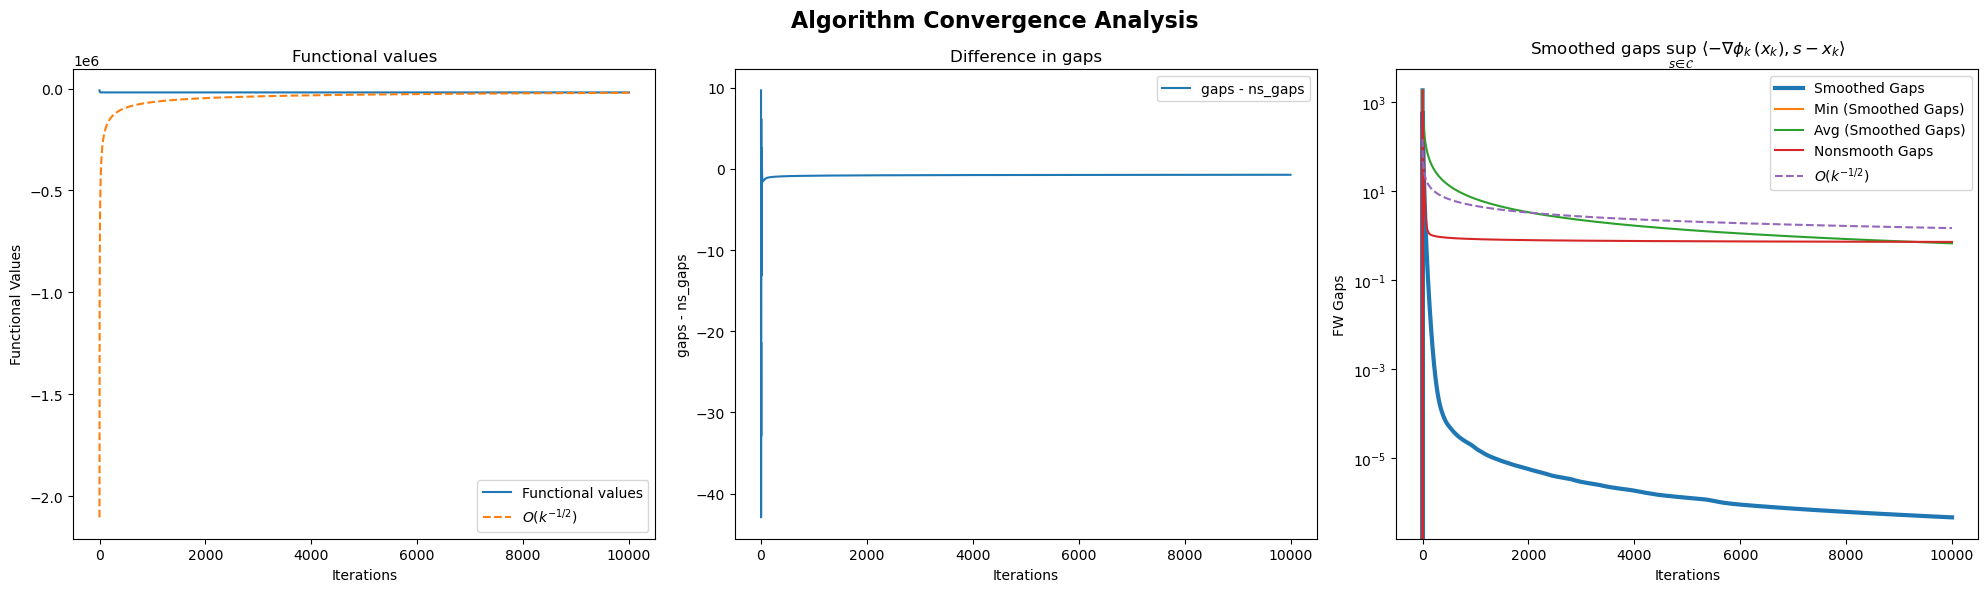

In [24]:
# Plot the convergence results
NonconvexSDP.plot_convergence()

In [25]:
np.linalg.norm(sol, ord='nuc')

100.00000000000011

In [26]:
gaps = NonconvexSDP.gaps
ns_gaps = NonconvexSDP.ns_gaps
n_steps = len(NonconvexSDP.func_vals)
min_gaps = np.zeros(n_steps)
avg_gaps = np.zeros(n_steps)

# Initialize the first elements
min_gaps[0] = gaps[0]
avg_gaps[0] = gaps[0]

for i in range(1, n_steps):
    # Update min_gaps
    min_gaps[i] = min(gaps[i], min_gaps[i-1])
    
    # Update avg_gaps using online algorithm
    avg_gaps[i] = avg_gaps[i-1] + (gaps[i] - avg_gaps[i-1]) / (i + 1)

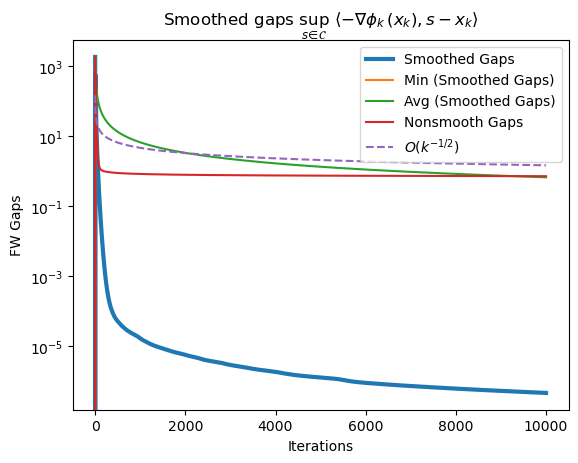

In [28]:
import matplotlib.pyplot as plt
# Plot gaps
plt.semilogy(range(n_steps), gaps, label='Smoothed Gaps', linewidth=3)
plt.semilogy(range(n_steps), min_gaps, label='Min (Smoothed Gaps)')
plt.semilogy(range(n_steps), avg_gaps, label='Avg (Smoothed Gaps)')
plt.semilogy(range(n_steps), ns_gaps, label='Nonsmooth Gaps')
plt.semilogy(range(0, n_steps), np.sqrt(n_steps + 1) * (1.1 * avg_gaps[n_steps//2]) / np.sqrt(np.array(range(1, n_steps + 1))), '--', label=r'$O\left(k^{-1/2}\right)$')
plt.title(r'Smoothed gaps $\sup_{s\in \mathcal{C}}\ \left\langle -\nabla \phi_k(x_k), s-x_k\right\rangle$')
plt.xlabel('Iterations')
plt.ylabel('FW Gaps')
plt.legend()
plt.show()